In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set a seed so our "random" data is reproducible
np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
# Generate 90 days of dates, starting 90 days ago up to today
num_days = 90
start_date = datetime(2026, 5, 1)
dates = [start_date + timedelta(days=i) for i in range(num_days)]

# Generate "normal" baseline data with natural random fluctuation
revenue = np.random.normal(loc=10000, scale=800, size=num_days)      # avg ₹10,000/day
orders = np.random.normal(loc=200, scale=15, size=num_days)          # avg 200 orders/day
traffic = np.random.normal(loc=5000, scale=300, size=num_days)       # avg 5000 visitors/day
cost = np.random.normal(loc=4000, scale=250, size=num_days)          # avg ₹4,000/day ad spend
refunds = np.random.normal(loc=50, scale=10, size=num_days)          # avg ₹50/day refunds

# Conversion rate = orders / traffic (a realistic derived metric)
conversion_rate = (orders / traffic) * 100

# Now plant 4 deliberate anomalies on specific days
revenue[20] = 25000       # Day 21: revenue spike (maybe a big sale)
refunds[35] = 400         # Day 36: refund spike (something went wrong with a product)
traffic[55] = 1200        # Day 56: traffic crash (site issue or ad campaign paused)
cost[70] = 9500           # Day 71: cost spike (ad spend went out of control)

# Put it all together into a DataFrame (this is pandas' version of an Excel sheet)
df = pd.DataFrame({
    "Date": dates,
    "Revenue": revenue.round(2),
    "Orders": orders.round(0).astype(int),
    "Traffic": traffic.round(0).astype(int),
    "Conversion_Rate": conversion_rate.round(2),
    "Cost": cost.round(2),
    "Refunds": refunds.round(2)
})

print(df.shape)
df.head(10)

(90, 7)


,Date,Revenue,Orders,Traffic,Conversion_Rate,Cost,Refunds
0,2026-05-01,10397.37,201,5188,3.88,4360.32,55.19
1,2026-05-02,9889.39,215,4743,4.52,3641.03,65.33
2,2026-05-03,10518.15,189,4679,4.05,4290.79,48.91
3,2026-05-04,11218.42,195,5145,3.79,4002.56,54.02
4,2026-05-05,9812.68,194,4933,3.94,3754.62,56.90
5,2026-05-06,9812.69,178,5214,3.41,4115.53,45.99
6,2026-05-07,11263.37,204,5142,3.98,4049.76,52.24
7,2026-05-08,10613.95,204,4978,4.10,3849.95,50.13
8,2026-05-09,9624.42,200,4746,4.22,4017.45,50.98
9,2026-05-10,10434.05,196,4546,4.32,3903.67,42.27


In [5]:
import os

folder_path = "/content/drive/MyDrive/AI_Anomaly_Agent"
os.makedirs(folder_path, exist_ok=True)

file_path = f"{folder_path}/business_data.xlsx"
df.to_excel(file_path, index=False)

print(f"Saved successfully to: {file_path}")

Saved successfully to: /content/drive/MyDrive/AI_Anomaly_Agent/business_data.xlsx


In [6]:
# Simulate what our "agent" will do: read the Excel file fresh, as if a manager just sent it
df_agent = pd.read_excel(file_path)

# Calculate day-to-day % change for each numeric metric
metrics = ["Revenue", "Orders", "Traffic", "Conversion_Rate", "Cost", "Refunds"]

for metric in metrics:
    df_agent[f"{metric}_pct_change"] = df_agent[metric].pct_change() * 100

# Show the last 10 rows so we can see the % change columns clearly
df_agent.tail(10)

,Date,Revenue,Orders,Traffic,Conversion_Rate,Cost,Refunds,Revenue_pct_change,Orders_pct_change,Traffic_pct_change,Conversion_Rate_pct_change,Cost_pct_change,Refunds_pct_change
80,2026-07-20,9824.26,187,4722,3.95,4077.73,53.84,16.817242,-1.058201,-9.747706,9.418283,3.321560,8.899676
81,2026-07-21,10285.69,188,4982,3.77,4368.84,49.67,4.696842,0.534759,5.506141,-4.556962,7.139021,-7.745171
82,2026-07-22,11182.32,199,4028,4.94,4214.41,29.33,8.717257,5.851064,-19.148936,31.034483,-3.534806,-40.950272
83,2026-07-23,9585.38,205,4693,4.37,3960.02,49.11,-14.280936,3.015075,16.509434,-11.538462,-6.036195,67.439482
84,2026-07-24,9353.21,204,4924,4.15,3995.25,36.96,-2.422126,-0.487805,4.922225,-5.034325,0.889642,-24.740379
85,2026-07-25,9598.59,212,4626,4.59,3749.37,56.70,2.623484,3.921569,-6.051990,10.602410,-6.154308,53.409091
86,2026-07-26,10732.32,200,5490,3.65,3995.37,53.67,11.811422,-5.660377,18.677043,-20.479303,6.561102,-5.343915
87,2026-07-27,10263.00,222,4571,4.85,3927.84,40.60,-4.372959,11.000000,-16.739526,32.876712,-1.690206,-24.352525
88,2026-07-28,9576.19,196,4868,4.03,4080.68,44.86,-6.692098,-11.711712,6.497484,-16.907216,3.891197,10.492611
89,2026-07-29,10410.61,241,5039,4.78,3793.19,39.41,8.713486,22.959184,3.512736,18.610422,-7.045149,-12.148908


In [7]:
# For each metric's % change column, calculate the average and standard deviation
anomaly_summary = {}

for metric in metrics:
    col = f"{metric}_pct_change"
    mean_change = df_agent[col].mean()
    std_change = df_agent[col].std()
    anomaly_summary[metric] = {"mean": mean_change, "std": std_change}
    print(f"{metric}: average change = {mean_change:.2f}%, typical spread (std) = {std_change:.2f}%")

Revenue: average change = 1.80%, typical spread (std) = 22.94%
Orders: average change = 0.76%, typical spread (std) = 10.65%
Traffic: average change = 2.76%, typical spread (std) = 30.79%
Conversion_Rate: average change = 1.38%, typical spread (std) = 15.52%
Cost: average change = 1.07%, typical spread (std) = 18.35%
Refunds: average change = 9.73%, typical spread (std) = 66.03%


In [8]:
# For each metric, mark a day as anomalous if its % change is more than 2 std devs from the mean
for metric in metrics:
    col = f"{metric}_pct_change"
    mean_change = anomaly_summary[metric]["mean"]
    std_change = anomaly_summary[metric]["std"]

    lower_bound = mean_change - 2 * std_change
    upper_bound = mean_change + 2 * std_change

    df_agent[f"{metric}_is_anomaly"] = (
        (df_agent[col] < lower_bound) | (df_agent[col] > upper_bound)
    )

# Let's see which days got flagged for ANY metric
anomaly_cols = [f"{m}_is_anomaly" for m in metrics]
df_agent["any_anomaly"] = df_agent[anomaly_cols].any(axis=1)

flagged_days = df_agent[df_agent["any_anomaly"] == True]
print(f"Total anomalous days flagged: {len(flagged_days)}")
flagged_days[["Date"] + anomaly_cols]

Total anomalous days flagged: 12


,Date,Revenue_is_anomaly,Orders_is_anomaly,Traffic_is_anomaly,Conversion_Rate_is_anomaly,Cost_is_anomaly,Refunds_is_anomaly
20,2026-05-21,True,False,False,False,False,False
21,2026-05-22,True,False,False,False,False,False
35,2026-06-05,False,False,False,False,False,True
36,2026-06-06,False,True,False,False,False,False
41,2026-06-11,False,False,False,True,False,False
55,2026-06-25,False,False,True,False,False,False
56,2026-06-26,False,False,True,False,False,False
70,2026-07-10,False,False,False,False,True,False
71,2026-07-11,False,False,False,False,True,False
74,2026-07-14,False,False,False,True,False,False


In [9]:
def generate_anomaly_summary(row, metrics, anomaly_summary):
    messages = []

    for metric in metrics:
        anomaly_col = f"{metric}_is_anomaly"
        change_col = f"{metric}_pct_change"

        if row[anomaly_col]:
            change_value = row[change_col]
            direction = "increased" if change_value > 0 else "decreased"

            message = (
                f"{metric.replace('_', ' ')} {direction} sharply "
                f"({change_value:+.1f}% vs previous day), "
                f"which is well outside its normal daily range."
            )
            messages.append(message)

    return " ".join(messages)

# Apply this function to every flagged day
flagged_days = df_agent[df_agent["any_anomaly"] == True].copy()
flagged_days["summary"] = flagged_days.apply(
    lambda row: generate_anomaly_summary(row, metrics, anomaly_summary), axis=1
)

# Display just the date and the readable summary
for idx, row in flagged_days.iterrows():
    print(f"📅 {row['Date'].date()}")
    print(f"   {row['summary']}")
    print()

📅 2026-05-21
   Revenue increased sharply (+181.8% vs previous day), which is well outside its normal daily range.

📅 2026-05-22
   Revenue decreased sharply (-60.7% vs previous day), which is well outside its normal daily range.

📅 2026-06-05
   Refunds increased sharply (+547.4% vs previous day), which is well outside its normal daily range.

📅 2026-06-06
   Orders decreased sharply (-20.6% vs previous day), which is well outside its normal daily range.

📅 2026-06-11
   Conversion Rate increased sharply (+46.1% vs previous day), which is well outside its normal daily range.

📅 2026-06-25
   Traffic decreased sharply (-78.7% vs previous day), which is well outside its normal daily range.

📅 2026-06-26
   Traffic increased sharply (+266.0% vs previous day), which is well outside its normal daily range.

📅 2026-07-10
   Cost increased sharply (+146.2% vs previous day), which is well outside its normal daily range.

📅 2026-07-11
   Cost decreased sharply (-57.3% vs previous day), which i

Chart saved to: /content/drive/MyDrive/AI_Anomaly_Agent/anomaly_charts.png


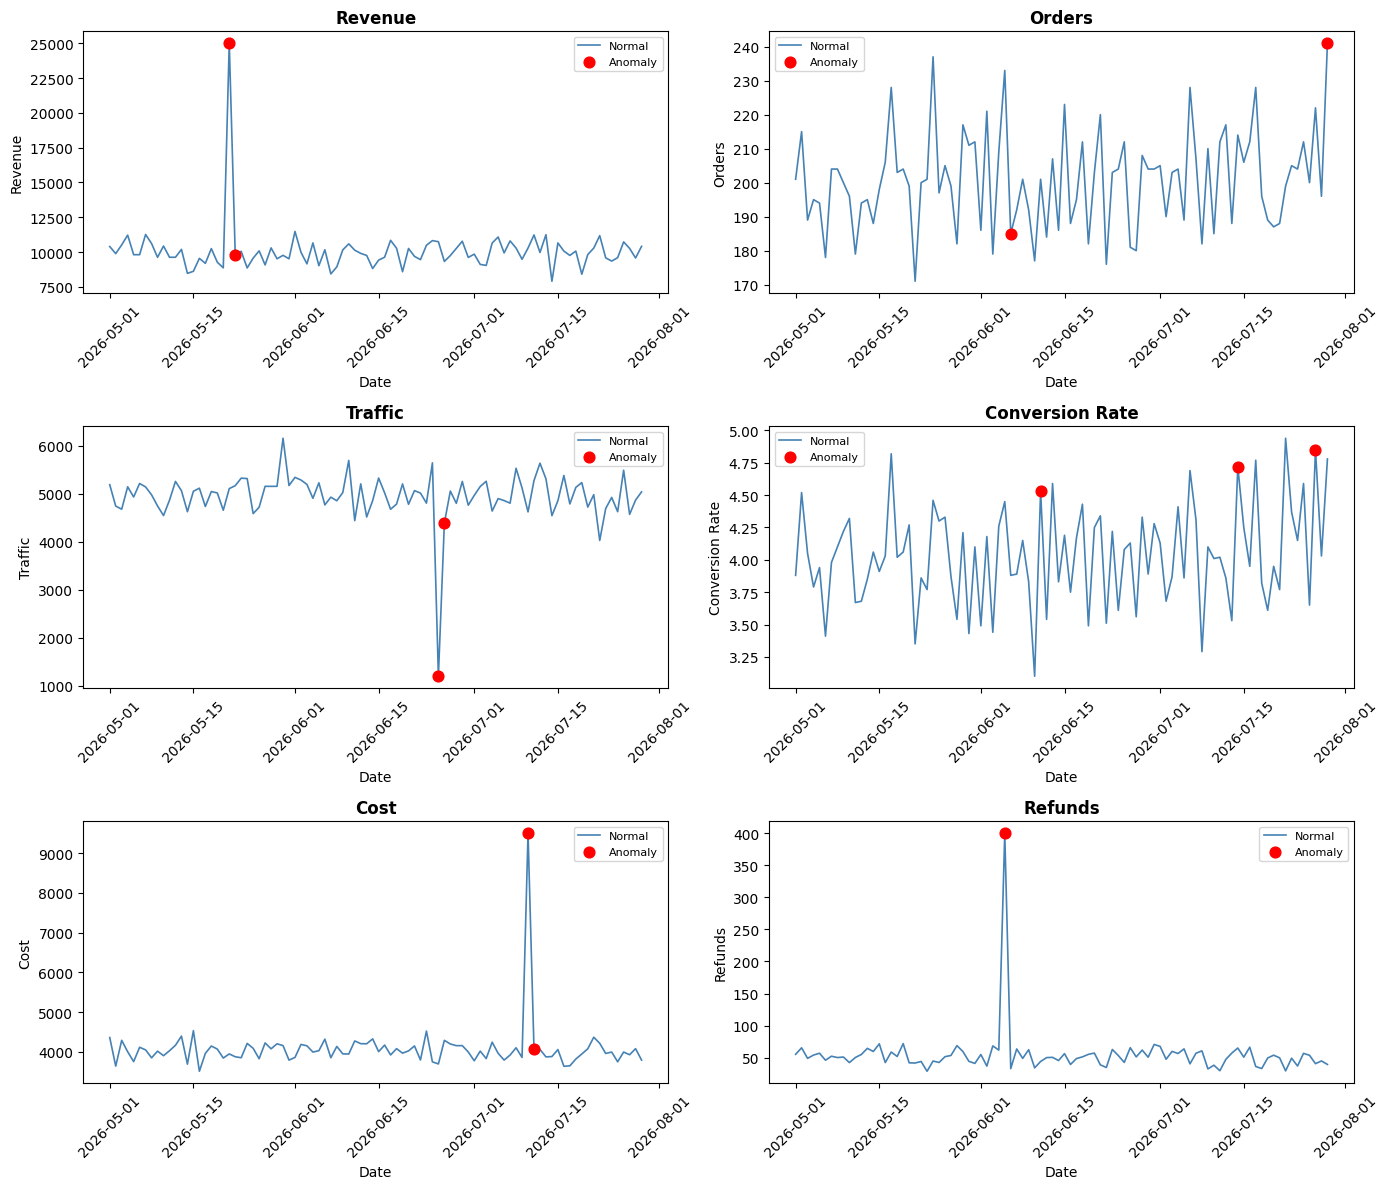

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()  # turn the 3x2 grid into a simple list of 6 plots

for i, metric in enumerate(metrics):
    ax = axes[i]
    anomaly_col = f"{metric}_is_anomaly"

    # Plot the normal line for all days
    ax.plot(df_agent["Date"], df_agent[metric], color="steelblue", linewidth=1.2, label="Normal")

    # Overlay red dots on the days flagged as anomalies for this metric
    anomaly_points = df_agent[df_agent[anomaly_col]]
    ax.scatter(anomaly_points["Date"], anomaly_points[metric],
               color="red", s=60, zorder=5, label="Anomaly")

    ax.set_title(metric.replace("_", " "), fontsize=12, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel(metric.replace("_", " "))
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Save the chart into our project folder too, so it becomes part of our deliverables
chart_path = f"{folder_path}/anomaly_charts.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
print(f"Chart saved to: {chart_path}")

plt.show()

In [11]:
from datetime import datetime as dt

def build_email_alert(flagged_days, metrics):
    num_anomalies = len(flagged_days)
    today_str = dt.now().strftime("%Y-%m-%d %H:%M")

    # Build the email subject line
    subject = f"⚠️ Business Anomaly Alert — {num_anomalies} issue(s) detected"

    # Build the email body
    body_lines = []
    body_lines.append(f"AI Anomaly Agent Report — Generated {today_str}")
    body_lines.append("=" * 55)
    body_lines.append(f"\nTotal anomalies detected: {num_anomalies}\n")

    for idx, row in flagged_days.iterrows():
        body_lines.append(f"Date: {row['Date'].date()}")
        body_lines.append(f"  {row['summary']}")
        body_lines.append("")  # blank line between entries

    body_lines.append("=" * 55)
    body_lines.append("This is an automated alert from the AI Anomaly Agent.")

    email_body = "\n".join(body_lines)

    return subject, email_body

# Generate the alert content
subject, email_body = build_email_alert(flagged_days, metrics)

print("TO: manager@company.com")
print(f"SUBJECT: {subject}")
print("-" * 55)
print(email_body)

TO: manager@company.com
SUBJECT: ⚠️ Business Anomaly Alert — 12 issue(s) detected
-------------------------------------------------------
AI Anomaly Agent Report — Generated 2026-08-22 07:10

Total anomalies detected: 12

Date: 2026-05-21
  Revenue increased sharply (+181.8% vs previous day), which is well outside its normal daily range.

Date: 2026-05-22
  Revenue decreased sharply (-60.7% vs previous day), which is well outside its normal daily range.

Date: 2026-06-05
  Refunds increased sharply (+547.4% vs previous day), which is well outside its normal daily range.

Date: 2026-06-06
  Orders decreased sharply (-20.6% vs previous day), which is well outside its normal daily range.

Date: 2026-06-11
  Conversion Rate increased sharply (+46.1% vs previous day), which is well outside its normal daily range.

Date: 2026-06-25
  Traffic decreased sharply (-78.7% vs previous day), which is well outside its normal daily range.

Date: 2026-06-26
  Traffic increased sharply (+266.0% vs prev

In [12]:
# Save the alert as a timestamped log file in the project folder
log_folder = f"{folder_path}/alert_logs"
os.makedirs(log_folder, exist_ok=True)

log_filename = f"alert_{dt.now().strftime('%Y%m%d_%H%M%S')}.txt"
log_path = f"{log_folder}/{log_filename}"

with open(log_path, "w", encoding="utf-8") as f:
    f.write(f"TO: manager@company.com\n")
    f.write(f"SUBJECT: {subject}\n")
    f.write("-" * 55 + "\n")
    f.write(email_body)

print(f"Alert saved to log: {log_path}")

Alert saved to log: /content/drive/MyDrive/AI_Anomaly_Agent/alert_logs/alert_20260822_071837.txt


In [13]:
# Build one consolidated final report
print("=" * 60)
print("AI ANOMALY AGENT — FINAL PROJECT SUMMARY")
print("=" * 60)

print(f"\nData period: {df_agent['Date'].min().date()} to {df_agent['Date'].max().date()}")
print(f"Total days analyzed: {len(df_agent)}")
print(f"Metrics monitored: {', '.join(metrics)}")
print(f"\nDetection method: 2-standard-deviation rule (per metric)")
print(f"Total anomalies flagged: {len(flagged_days)}")

print(f"\n--- Files generated ---")
print(f"Dataset:      {file_path}")
print(f"Anomaly chart: {chart_path}")
print(f"Alert log:    {log_path}")

print(f"\n--- Most recent alert (preview) ---")
print(f"Subject: {subject}")
print(f"Anomalies in this alert: {len(flagged_days)}")

print("\n" + "=" * 60)
print("Project pipeline: Read data -> Detect anomalies -> ")
print("Summarize in plain English -> Visualize -> Alert -> Log")
print("=" * 60)

AI ANOMALY AGENT — FINAL PROJECT SUMMARY

Data period: 2026-05-01 to 2026-07-29
Total days analyzed: 90
Metrics monitored: Revenue, Orders, Traffic, Conversion_Rate, Cost, Refunds

Detection method: 2-standard-deviation rule (per metric)
Total anomalies flagged: 12

--- Files generated ---
Dataset:      /content/drive/MyDrive/AI_Anomaly_Agent/business_data.xlsx
Anomaly chart: /content/drive/MyDrive/AI_Anomaly_Agent/anomaly_charts.png
Alert log:    /content/drive/MyDrive/AI_Anomaly_Agent/alert_logs/alert_20260822_071837.txt

--- Most recent alert (preview) ---
Subject: ⚠️ Business Anomaly Alert — 12 issue(s) detected
Anomalies in this alert: 12

Project pipeline: Read data -> Detect anomalies -> 
Summarize in plain English -> Visualize -> Alert -> Log
